In [1]:
import numpy as np
from scipy import stats
from scipy.stats import norm, t, chi2, f, binom, poisson, expon, uniform, bernoulli, geom
import matplotlib.pyplot as plt

$$ P(A^c \cap B^c \cap C^c) = P(A^c) \cdot P(B^c) \cdot P(C^c)$$
$$ P(A^c \cup B^c \cup C^c) = 1 - \prod_{i-1}^n(1-P(A_i)) $$

In [ ]:
# P_X for P(X)
P_A = 0.4
P_B = 0.35
P_C = 0.2


P_Ac = 1 - P_A
P_Bc = 1 - P_B
P_Cc = 1 - P_C

#Sansynlighed Foreningsmængden
P_forening_Ac_Bc_Cc = P_Ac * P_Bc * P_Cc

print(round(P_forening_Ac_Bc_Cc*100, 2), "%")

31.2 %


In [ ]:
#Sansynlighed Fællesmængde
P_Fælles_Ac_Bc_Cc_ = 1-P_forening_Ac_Bc_Cc
print(round(P_Fælles_Ac_Bc_Cc_*100, 2), "%")

68.8 %


In [7]:
P_A_only = P_A*P_Bc*P_Cc
P_B_only = P_Ac*P_B*P_Cc
P_C_only = P_Ac*P_Bc*P_C

P_total = P_A_only+P_B_only+P_C_only

print(round(P_total*100, 2), "%")

45.4 %


# new ==================================================

$$ F_X(x) = \begin{cases} 0 & \text{for}\: x < 2 \\\frac{x-2}{4} & \text{for}\: x \leq 6 \\1 & \text{otherwise} \end{cases} $$

In [10]:
# Bestem tæthedsfunktionen f_X(x) fra fordelingsfunktionen F_X(x)
# DANSK: f_X(x) = d/dx F_X(x)
# ENGLISH: f_X(x) = d/dx F_X(x)
# LaTeX: f_X(x) = \frac{d}{dx} F_X(x)
from sympy import symbols, diff, simplify, latex, Piecewise

# Definer symbolsk variabel
x = symbols('x', real=True)

# Definer fordelingsfunktion F_X(x) (CDF)
# Eksempel: F_X(x) = x³ for x ∈ [0,1]
# F_X = x**3  # Indsæt din CDF her

# Hvis CDF er stykkevis defineret, brug Piecewise:
F_X = Piecewise(
    (0, x < 2),
    ((x-2)/4, (x >= 2) & (x <= 6)),
    (1, x > 6)
)

print("Fordelingsfunktion (CDF):")
print(f"  F_X(x) = {F_X}")
print(fr"  LaTeX: F_X(x) = {latex(F_X)}")
print(fr"$$ F_X(x) = {latex(F_X)} $$")

# Beregn tæthedsfunktion ved differentiering: f_X(x) = d/dx F_X(x)
print("\nDifferentierer...")
f_X = diff(F_X, x)
f_X_simplified = simplify(f_X)

print("\nTæthedsfunktion (PDF):")
print(f"  f_X(x) = d/dx F_X(x)")
print(f"  f_X(x) = {f_X_simplified}")
print(fr"  LaTeX: f_X(x) = {latex(f_X_simplified)}")
print(fr"$$ f_X(x) = {latex(f_X_simplified)} $$")

# Verificer at integral af PDF = 1 (hvis muligt)
print("\nVerifikation (hvis CDF går fra 0 til 1):")
from sympy import integrate as sym_integrate
try:
    # Integrer f_X over hele support
    total = sym_integrate(f_X_simplified, (x, 0, 1))
    total_simplified = simplify(total)
    print(fr"\int_{{{0}}}^{{{1}}} f_X(x) dx = {total_simplified}")
    if total_simplified == 1:
        print("✓ PDF integrerer til 1 (gyldig tæthedsfunktion)")
    else:
        print(f"⚠ PDF integrerer til {total_simplified} (ikke 1!)")
except:
    print("(Kan ikke verificere integral symbolsk)")

Fordelingsfunktion (CDF):
  F_X(x) = Piecewise((0, x < 2), (x/4 - 1/2, x <= 6), (1, True))
  LaTeX: F_X(x) = \begin{cases} 0 & \text{for}\: x < 2 \\\frac{x}{4} - \frac{1}{2} & \text{for}\: x \leq 6 \\1 & \text{otherwise} \end{cases}
$$ F_X(x) = \begin{cases} 0 & \text{for}\: x < 2 \\\frac{x}{4} - \frac{1}{2} & \text{for}\: x \leq 6 \\1 & \text{otherwise} \end{cases} $$

Differentierer...

Tæthedsfunktion (PDF):
  f_X(x) = d/dx F_X(x)
  f_X(x) = Piecewise((0, x < 2), (1/4, x <= 6), (0, True))
  LaTeX: f_X(x) = \begin{cases} 0 & \text{for}\: x < 2 \\\frac{1}{4} & \text{for}\: x \leq 6 \\0 & \text{otherwise} \end{cases}
$$ f_X(x) = \begin{cases} 0 & \text{for}\: x < 2 \\\frac{1}{4} & \text{for}\: x \leq 6 \\0 & \text{otherwise} \end{cases} $$

Verifikation (hvis CDF går fra 0 til 1):
\int_{0}^{1} f_X(x) dx = 0
⚠ PDF integrerer til 0 (ikke 1!)


$$ f_X(x) = \begin{cases} 0 & \text{for}\: x < 2 \\\frac{1}{4} & \text{for}\: x \leq 6 \\0 & \text{otherwise} \end{cases} $$

KOMPLET FÆLLES FORDELINGSANALYSE - DETALJERET
COMPLETE JOINT DISTRIBUTION ANALYSIS - DETAILED
\nFælles PDF: f_{{X,Y}}(x,y) = c x y
Region: x \in [0, 2], y \in [0, 3]
$$ f_{{X,Y}}(x,y) = c x y $$

1. NORMALISERINGSKONSTANT

Formel: For at f_{X,Y} skal være en gyldig PDF:
$$ \int_{0}^{2} \int_{0}^{3} f_{{X,Y}}(x,y) \, dy \, dx = 1 $$

Beregner dobbelt integral...
Resultat: \int_{0}^{2} \int_{0}^{3} f_{{X,Y}}(x,y) dy dx = 9 c
$$ \int_{0}^{2} \int_{0}^{3} c x y \, dy \, dx = 9 c $$
\nLøser ligning: 9 c = 1
$$ 9 c = 1 $$
\nLøsning: c = \frac{1}{9}
$$ c = \frac{1}{9} $$
\nNormaliseret PDF: f_{{X,Y}}(x,y) = \frac{x y}{9}
$$ f_{{X,Y}}(x,y) = \frac{x y}{9} $$

2. MARGINALFORDELINGER

--- Marginal for X ---

Formel: Marginal PDF for X:
$$ f_X(x) = \int_{0}^{3} f_{{X,Y}}(x,y) \, dy $$
\nBeregner: f_X(x) = \int_{0}^{3} \frac{x y}{9} dy
\nResultat: f_X(x) = \frac{x}{2}
$$ f_X(x) = \frac{x}{2} $$

--- Marginal for Y ---

Formel: Marginal PDF for Y:
$$ f_Y(y) = \int_{0}^{2} f_{{X,Y}}(x,y) \, dx $$
\n

## FORVENTNINGSVÆRDI REGLER / EXPECTED VALUE RULES

### Grundlæggende definition / Basic definition

**Diskret variabel:**
$$ E[X] = \sum_x x \cdot f_X(x) = \sum_x x \cdot P(X=x) $$

**Kontinuert variabel:**
$$ E[X] = \int_{-\infty}^{\infty} x \cdot f_X(x) \, dx $$

---

### Linearitet / Linearity

**Konstant:**
$$ E[c] = c $$

**Multiplikation med konstant:**
$$ E[aX] = a \cdot E[X] $$

**Addition af konstant:**
$$ E[X + b] = E[X] + b $$

**Lineær transformation:**
$$ E[aX + b] = a \cdot E[X] + b $$

**Linearitet (sum af variable):**
$$ E[X + Y] = E[X] + E[Y] \quad \text{(gælder altid, uanset afhængighed!)} $$

**Generel lineær kombination:**
$$ E[aX + bY + c] = a \cdot E[X] + b \cdot E[Y] + c $$

**Sum af n variable:**
$$ E\left[\sum_{i=1}^n X_i\right] = \sum_{i=1}^n E[X_i] $$

---

### Produkt af variable / Product of variables

**Uafhængige variable:**
$$ E[XY] = E[X] \cdot E[Y] \quad \text{hvis } X \perp Y $$

**Generelt (relation til kovarians):**
$$ E[XY] = \text{Cov}(X,Y) + E[X] \cdot E[Y] $$

**Konstant gange variabel:**
$$ E[aXY] = a \cdot E[XY] $$

---

### Funktioner af variable / Functions of variables

**LOTUS (Law of the Unconscious Statistician) - Diskret:**
$$ E[g(X)] = \sum_x g(x) \cdot f_X(x) $$

**LOTUS - Kontinuert:**
$$ E[g(X)] = \int_{-\infty}^{\infty} g(x) \cdot f_X(x) \, dx $$

**To variable - Diskret:**
$$ E[g(X,Y)] = \sum_x \sum_y g(x,y) \cdot f_{X,Y}(x,y) $$

**To variable - Kontinuert:**
$$ E[g(X,Y)] = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} g(x,y) \cdot f_{X,Y}(x,y) \, dx \, dy $$

---

### Fælles fordelinger / Joint distributions

**E[X] fra marginal tæthed (kontinuert):**
$$ E[X] = \int_{-\infty}^{\infty} x \cdot f_X(x) \, dx $$

hvor $$ f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x,y) \, dy $$

**E[Y] fra marginal tæthed (kontinuert):**
$$ E[Y] = \int_{-\infty}^{\infty} y \cdot f_Y(y) \, dy $$

hvor $$ f_Y(y) = \int_{-\infty}^{\infty} f_{X,Y}(x,y) \, dx $$

**E[XY] fra fælles tæthed (kontinuert):**
$$ E[XY] = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} xy \cdot f_{X,Y}(x,y) \, dx \, dy $$

**E[X] fra marginal PMF (diskret):**
$$ E[X] = \sum_x x \cdot f_X(x) $$

hvor $$ f_X(x) = \sum_y f_{X,Y}(x,y) $$

**E[Y] fra marginal PMF (diskret):**
$$ E[Y] = \sum_y y \cdot f_Y(y) $$

hvor $$ f_Y(y) = \sum_x f_{X,Y}(x,y) $$

**E[XY] fra fælles PMF (diskret):**
$$ E[XY] = \sum_x \sum_y xy \cdot f_{X,Y}(x,y) $$

---

### Betinget forventning / Conditional expectation

**Diskret:**
$$ E[X|Y=y] = \sum_x x \cdot f_{X|Y}(x|y) = \sum_x x \cdot \frac{f_{X,Y}(x,y)}{f_Y(y)} $$

**Kontinuert:**
$$ E[X|Y=y] = \int_{-\infty}^{\infty} x \cdot f_{X|Y}(x|y) \, dx = \int_{-\infty}^{\infty} x \cdot \frac{f_{X,Y}(x,y)}{f_Y(y)} \, dx $$

**Law of Total Expectation:**
$$ E[X] = E[E[X|Y]] $$

---

### Stikprøve middelværdi / Sample mean

**Definition:**
$$ \bar{X} = \frac{1}{n}\sum_{i=1}^n X_i $$

**Forventning:**
$$ E[\bar{X}] = E\left[\frac{1}{n}\sum_{i=1}^n X_i\right] = \frac{1}{n}\sum_{i=1}^n E[X_i] = \mu $$

(hvis alle X_i$ har samme forventning $\mu$)

$$ E[Y] = E[3X+2] $$

$$ E[3X+2] = 3 \cdot E[X]+2

In [13]:
# Beregn E[X] og Var(X) for kontinuert stokastisk variabel
# DANSK: Middelværdi E[X] = ∫ x·f(x) dx
# DANSK: Varians Var(X) = E[X²] - E[X]²
# ENGLISH: Expected value E[X] = ∫ x·f(x) dx
# ENGLISH: Variance Var(X) = E[X²] - E[X]²
# LaTeX: E[X] = \int_{-\infty}^{\infty} x \cdot f_X(x) \, dx
# LaTeX: E[X^2] = \int_{-\infty}^{\infty} x^2 \cdot f_X(x) \, dx
# LaTeX: Var(X) = E[X^2] - E[X]^2
from scipy import integrate

# Definer tæthedsfunktion f_X(x)
def f_X(x):
    return 1/4  # Eksempel: f(x) = 3x² for x ∈ [0,1]

# Integrationsgränser
a = 2  # Nedre grænse
b = 6  # Øvre grænse

# Beregn E[X] = ∫ x·f(x) dx
E_X, _ = integrate.quad(lambda x: x * f_X(x), a, b)

# Beregn E[X²] = ∫ x²·f(x) dx
E_X2, _ = integrate.quad(lambda x: x**2 * f_X(x), a, b)

# Beregn Var(X) = E[X²] - E[X]²
Var_X = E_X2 - E_X**2

print(f"E[X] = {E_X:.4f}")
print(f"E[X²] = {E_X2:.4f}")
print(f"Var(X) = {Var_X:.4f}")
print(f"SD(X) = {np.sqrt(Var_X):.4f}")

E_Y = 3*E_X+2
print(f"E[Y] = {E_Y}")

E[X] = 4.0000
E[X²] = 17.3333
Var(X) = 1.3333
SD(X) = 1.1547
E[Y] = 14.0


In [19]:
# Beregn PDF for transformeret stokastisk variabel: Y = g(X)
# DANSK: Find f_Y(y) når Y = g(X) og f_X(x) er kendt
# ENGLISH: Find f_Y(y) when Y = g(X) and f_X(x) is known
# LaTeX: f_Y(y) = f_X(g^{-1}(y)) \cdot \left| \frac{d}{dy} g^{-1}(y) \right|
from sympy import symbols, diff, simplify, latex, solve, Abs

# Definer symbolske variable
x, y = symbols('x y', real=True)

# Definer PDF for X
f_X = 1/4  # Eksempel: f_X(x) = (x-1)/2 for x ∈ [1,3]
x_min, x_max = 2, 6  # Support for X

# Definer transformationen Y = g(X)
g = 3*x+2  # Eksempel: Y = X - 4 (forskydning)

print("="*70)
print("TRANSFORMATION AF STOKASTISK VARIABEL")
print("="*70)

print(f"\nPDF for X: f_X(x) = {f_X}")
print(fr"LaTeX: f_X(x) = {latex(f_X)}")
print(fr"$$ f_X(x) = {latex(f_X)} $$")
print(f"Support: x ∈ [{x_min}, {x_max}]")

print(f"\nTransformation: Y = g(X) = {g}")
print(fr"LaTeX: Y = {latex(g)}")
print(fr"$$ Y = {latex(g)} $$")

# --- TRIN 1: Find den inverse funktion g^{-1}(y) ---
print("\n" + "="*70)
print("TRIN 1: FIND INVERS FUNKTION")
print("="*70)

# Løs y = g(x) for x
inverse_solutions = solve(y - g, x)
if inverse_solutions:
    g_inv = inverse_solutions[0]  # Tag den første løsning
    print(f"\nLøser: y = {g} for x")
    print(f"Invers funktion: x = g⁻¹(y) = {g_inv}")
    print(fr"LaTeX: x = {latex(g_inv)}")
    print(fr"$$ x = g^{{-1}}(y) = {latex(g_inv)} $$")
else:
    print("\n⚠ Kunne ikke finde invers funktion!")
    g_inv = None

if g_inv is not None:
    # --- TRIN 2: Beregn Jacobi-determinanten ---
    print("\n" + "="*70)
    print("TRIN 2: BEREGN JACOBI-DETERMINANT")
    print("="*70)
    
    # Differentier g^{-1}(y) med hensyn til y
    jacobian = diff(g_inv, y)
    jacobian_simplified = simplify(jacobian)
    jacobian_abs = Abs(jacobian_simplified)
    
    print(f"\nDifferentier: d/dy[g⁻¹(y)] = d/dy[{g_inv}]")
    print(f"Resultat: {jacobian_simplified}")
    print(fr"LaTeX: \frac{{d}}{{dy}} g^{{-1}}(y) = {latex(jacobian_simplified)}")
    print(fr"$$ \frac{{d}}{{dy}} g^{{-1}}(y) = {latex(jacobian_simplified)} $$")
    
    print(f"\nNumerisk værdi: |d/dy g⁻¹(y)| = {jacobian_abs}")
    print(fr"$$ \left| \frac{{d}}{{dy}} g^{{-1}}(y) \right| = {latex(jacobian_abs)} $$")
    
    # --- TRIN 3: Anvend transformationsformlen ---
    print("\n" + "="*70)
    print("TRIN 3: ANVEND TRANSFORMATIONSFORMEL")
    print("="*70)
    
    print("\nFormel: f_Y(y) = f_X(g⁻¹(y)) · |d/dy g⁻¹(y)|")
    print(fr"$$ f_Y(y) = f_X(g^{{-1}}(y)) \cdot \left| \frac{{d}}{{dy}} g^{{-1}}(y) \right| $$")
    
    # Substituer x = g^{-1}(y) i f_X(x)
    f_Y = f_X * jacobian_abs
    f_Y_simplified = simplify(f_Y)
    
    print(f"\nSubstituer x = {g_inv} i f_X(x) = {f_X}")
    print(f"f_Y(y) = {f_Y_simplified}")
    print(fr"LaTeX: f_Y(y) = {latex(f_Y_simplified)}")
    print(fr"$$ f_Y(y) = {latex(f_Y_simplified)} $$")
    
    # --- TRIN 4: Bestem support for Y ---
    print("\n" + "="*70)
    print("TRIN 4: BESTEM SUPPORT/INTERVAL FOR Y")
    print("="*70)
    
    print("\nMetode: Beregn y_min = g(x_min) og y_max = g(x_max)")
    print("Tjek om g er voksende eller aftagende for at finde det korrekte interval")
    
    # Beregn y_min og y_max
    y_at_xmin = g.subs(x, x_min)
    y_at_xmax = g.subs(x, x_max)
    
    print(f"\ny ved nedre grænse: g({x_min}) = {y_at_xmin}")
    print(f"y ved øvre grænse: g({x_max}) = {y_at_xmax}")
    
    # Check om g er voksende eller aftagende
    diff_check = simplify(y_at_xmax - y_at_xmin)
    
    if diff_check > 0:
        y_min_val, y_max_val = y_at_xmin, y_at_xmax
        print(f"\ng er VOKSENDE (g(x_max) > g(x_min))")
        print(f"Derfor: Y ∈ [g(x_min), g(x_max)] = [{y_min_val}, {y_max_val}]")
    elif diff_check < 0:
        y_min_val, y_max_val = y_at_xmax, y_at_xmin
        print(f"\ng er AFTAGENDE (g(x_max) < g(x_min))")
        print(f"Derfor: Y ∈ [g(x_max), g(x_min)] = [{y_min_val}, {y_max_val}] (omvendt!)")
    else:
        y_min_val, y_max_val = y_at_xmin, y_at_xmax
        print(f"\ng er KONSTANT eller ubestemmelig")
    
    print(f"\n→ X-support: x ∈ [{x_min}, {x_max}]")
    print(f"→ Y-support: y ∈ [{y_min_val}, {y_max_val}]")
    print(fr"$$ X \in [{latex(x_min)}, {latex(x_max)}] \quad \Rightarrow \quad Y \in [{latex(y_min_val)}, {latex(y_max_val)}] $$")
    
    # --- OPSUMMERING ---
    print("\n" + "="*70)
    print("OPSUMMERING / SUMMARY")
    print("="*70)
    
    print(f"\nOriginal variabel X:")
    print(f"  PDF: f_X(x) = {f_X}")
    print(f"  Support: x ∈ [{x_min}, {x_max}]")
    
    print(f"\nTransformation: Y = {g}")
    
    print(f"\nTransformeret variabel Y:")
    print(f"  PDF: f_Y(y) = {f_Y_simplified}")
    print(f"  Support: y ∈ [{y_min_val}, {y_max_val}]")
    
    print(f"\nLaTeX:")
    print(fr"$$ f_Y(y) = {latex(f_Y_simplified)}, \quad y \in [{latex(y_min_val)}, {latex(y_max_val)}] $$")

TRANSFORMATION AF STOKASTISK VARIABEL

PDF for X: f_X(x) = 0.25
LaTeX: f_X(x) = 0.25
$$ f_X(x) = 0.25 $$
Support: x ∈ [2, 6]

Transformation: Y = g(X) = 3*x + 2
LaTeX: Y = 3 x + 2
$$ Y = 3 x + 2 $$

TRIN 1: FIND INVERS FUNKTION

Løser: y = 3*x + 2 for x
Invers funktion: x = g⁻¹(y) = y/3 - 2/3
LaTeX: x = \frac{y}{3} - \frac{2}{3}
$$ x = g^{-1}(y) = \frac{y}{3} - \frac{2}{3} $$

TRIN 2: BEREGN JACOBI-DETERMINANT

Differentier: d/dy[g⁻¹(y)] = d/dy[y/3 - 2/3]
Resultat: 1/3
LaTeX: \frac{d}{dy} g^{-1}(y) = \frac{1}{3}
$$ \frac{d}{dy} g^{-1}(y) = \frac{1}{3} $$

Numerisk værdi: |d/dy g⁻¹(y)| = 1/3
$$ \left| \frac{d}{dy} g^{-1}(y) \right| = \frac{1}{3} $$

TRIN 3: ANVEND TRANSFORMATIONSFORMEL

Formel: f_Y(y) = f_X(g⁻¹(y)) · |d/dy g⁻¹(y)|
$$ f_Y(y) = f_X(g^{-1}(y)) \cdot \left| \frac{d}{dy} g^{-1}(y) \right| $$

Substituer x = y/3 - 2/3 i f_X(x) = 0.25
f_Y(y) = 0.0833333333333333
LaTeX: f_Y(y) = 0.0833333333333333
$$ f_Y(y) = 0.0833333333333333 $$

TRIN 4: BESTEM SUPPORT/INTERVAL FOR Y

Metode:

$$ f_Y(y) = 0.0833333333333333, \quad y \in [8, 20] $$

In [20]:
# Beregn E[X] og Var(X) for kontinuert stokastisk variabel
# DANSK: Middelværdi E[X] = ∫ x·f(x) dx
# DANSK: Varians Var(X) = E[X²] - E[X]²
# ENGLISH: Expected value E[X] = ∫ x·f(x) dx
# ENGLISH: Variance Var(X) = E[X²] - E[X]²
# LaTeX: E[X] = \int_{-\infty}^{\infty} x \cdot f_X(x) \, dx
# LaTeX: E[X^2] = \int_{-\infty}^{\infty} x^2 \cdot f_X(x) \, dx
# LaTeX: Var(X) = E[X^2] - E[X]^2
from scipy import integrate

# Definer tæthedsfunktion f_X(x)
def f_X(x):
    return 0.08333333333333333333  # Eksempel: f(x) = 3x² for x ∈ [0,1]

# Integrationsgränser
a = 8  # Nedre grænse
b = 20  # Øvre grænse

# Beregn E[X] = ∫ x·f(x) dx
E_X, _ = integrate.quad(lambda x: x * f_X(x), a, b)

# Beregn E[X²] = ∫ x²·f(x) dx
E_X2, _ = integrate.quad(lambda x: x**2 * f_X(x), a, b)

# Beregn Var(X) = E[X²] - E[X]²
Var_X = E_X2 - E_X**2

print(f"E[X] = {E_X:.4f}")
print(f"E[X²] = {E_X2:.4f}")
print(f"Var(X) = {Var_X:.4f}")
print(f"SD(X) = {np.sqrt(Var_X):.4f}")

E[X] = 14.0000
E[X²] = 208.0000
Var(X) = 12.0000
SD(X) = 3.4641


$$ f_Y(y) = f_X(g^{-1}(y)) \cdot \left| \frac{d}{dy} g^{-1}(y) \right| $$

# new ================================================================================

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# FÆLLES DISKRET FORDELING - KOMPLET ANALYSE
# COMPLETE JOINT DISCRETE DISTRIBUTION ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════

print('═══════════════════════════════════════════════════════════════════════════')
print('FORMLER')
print('═══════════════════════════════════════════════════════════════════════════')
print()
from IPython.display import display, Markdown
display(Markdown(r'''
**Fælles PMF:**
$$ f_{X,Y}(x,y) = P(X=x, Y=y) $$

**Marginalfordelinger:**
$$ f_X(x) = \sum_{\text{alle } y} f_{X,Y}(x,y), \quad f_Y(y) = \sum_{\text{alle } x} f_{X,Y}(x,y) $$

**Forventningsværdier:**
$$ E[X] = \sum_{\text{alle } x} x \cdot f_X(x), \quad E[Y] = \sum_{\text{alle } y} y \cdot f_Y(y) $$

$$ E[XY] = \sum_{\text{alle } x} \sum_{\text{alle } y} xy \cdot f_{X,Y}(x,y) $$

**Varianser:**
$$ \text{Var}(X) = E[X^2] - E[X]^2, \quad \text{Var}(Y) = E[Y^2] - E[Y]^2 $$

**Kovarians:**
$$ \text{Cov}(X,Y) = E[XY] - E[X]E[Y] $$

**Korrelation:**
$$ \rho(X,Y) = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Var}(X) \cdot \text{Var}(Y)}} $$

**Uafhængighed:**
$$ X \perp Y \Leftrightarrow f_{X,Y}(x,y) = f_X(x) \cdot f_Y(y) \text{ for alle } x,y $$
'''))
print()

# DATA INPUT
# Fælles PMF matrix (rows = X værdier, columns = Y værdier)
f_X = np.array([
    0.5,0.3,0.2
])

# X og Y værdier
X_vals = np.array([0,1,2])  # Skal matche antal rækker

print('═══════════════════════════════════════════════════════════════════════════')
print('DATA')
print('═══════════════════════════════════════════════════════════════════════════')
print(f'X værdier: {X_vals}')
print()
print('PMF f_{X}(x):')
print(f_X)
print()

# ───────────────────────────────────────────────────────────────────────────
# FORVENTNINGSVÆRDIER
# ───────────────────────────────────────────────────────────────────────────

# Beregn E[X] og E[Y]
E_X = np.sum(X_vals * f_X)

# Beregn E[X²] og E[Y²]
E_X2 = np.sum(X_vals**2 * f_X)

print('═══════════════════════════════════════════════════════════════════════════')
print('FORVENTNINGSVÆRDIER')
print('═══════════════════════════════════════════════════════════════════════════')
print()
print('middelværdier:')
print(f'  E[X] = Σ x·f_X(x) = {E_X:.4f}')
print()
print('Højere momenter:')
print(f'  E[X²] = Σ x²·f_X(x) = {E_X2:.4f}')
print()

# ───────────────────────────────────────────────────────────────────────────
# VARIANSER
# ───────────────────────────────────────────────────────────────────────────

# Beregn varianser: Var(X) = E[X²] - E[X]²
Var_X = E_X2 - E_X**2

# Beregn standardafvigelser
SD_X = np.sqrt(Var_X)

print('═══════════════════════════════════════════════════════════════════════════')
print('VARIANSER OG STANDARDAFVIGELSER')
print('═══════════════════════════════════════════════════════════════════════════')
print()
print('Var(X) = E[X²] - E[X]²:')
print(f'  Var(X) = {E_X2:.4f} - {E_X:.4f}² = {Var_X:.4f}')
print(f'  SD(X) = √Var(X) = {SD_X:.4f}')
print()

# ───────────────────────────────────────────────────────────────────────────
# SAMMENDRAG
# ───────────────────────────────────────────────────────────────────────────

print('═══════════════════════════════════════════════════════════════════════════')
print('SAMMENDRAG / SUMMARY')
print('═══════════════════════════════════════════════════════════════════════════')
print()
print(f'E[X] = {E_X:.4f},  Var(X) = {Var_X:.4f},  SD(X) = {SD_X:.4f}')
print()
print('═══════════════════════════════════════════════════════════════════════════')

═══════════════════════════════════════════════════════════════════════════
FORMLER
═══════════════════════════════════════════════════════════════════════════




**Fælles PMF:**
$$ f_{X,Y}(x,y) = P(X=x, Y=y) $$

**Marginalfordelinger:**
$$ f_X(x) = \sum_{\text{alle } y} f_{X,Y}(x,y), \quad f_Y(y) = \sum_{\text{alle } x} f_{X,Y}(x,y) $$

**Forventningsværdier:**
$$ E[X] = \sum_{\text{alle } x} x \cdot f_X(x), \quad E[Y] = \sum_{\text{alle } y} y \cdot f_Y(y) $$

$$ E[XY] = \sum_{\text{alle } x} \sum_{\text{alle } y} xy \cdot f_{X,Y}(x,y) $$

**Varianser:**
$$ \text{Var}(X) = E[X^2] - E[X]^2, \quad \text{Var}(Y) = E[Y^2] - E[Y]^2 $$

**Kovarians:**
$$ \text{Cov}(X,Y) = E[XY] - E[X]E[Y] $$

**Korrelation:**
$$ \rho(X,Y) = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Var}(X) \cdot \text{Var}(Y)}} $$

**Uafhængighed:**
$$ X \perp Y \Leftrightarrow f_{X,Y}(x,y) = f_X(x) \cdot f_Y(y) \text{ for alle } x,y $$



═══════════════════════════════════════════════════════════════════════════
DATA
═══════════════════════════════════════════════════════════════════════════
X værdier: [0 1 2]

PMF f_{X}(x):
[0.5 0.3 0.2]

═══════════════════════════════════════════════════════════════════════════
FORVENTNINGSVÆRDIER
═══════════════════════════════════════════════════════════════════════════

middelværdier:
  E[X] = Σ x·f_X(x) = 0.7000

Højere momenter:
  E[X²] = Σ x²·f_X(x) = 1.1000

═══════════════════════════════════════════════════════════════════════════
VARIANSER OG STANDARDAFVIGELSER
═══════════════════════════════════════════════════════════════════════════

Var(X) = E[X²] - E[X]²:
  Var(X) = 1.1000 - 0.7000² = 0.6100
  SD(X) = √Var(X) = 0.7810

═══════════════════════════════════════════════════════════════════════════
SAMMENDRAG / SUMMARY
═══════════════════════════════════════════════════════════════════════════

E[X] = 0.7000,  Var(X) = 0.6100,  SD(X) = 0.7810

════════════════════════════

In [40]:
# Beregn kumulativ fordelingsfunktion (CDF) fra PMF
# DANSK: F_X(x) = P(X ≤ x) = Σ_{t≤x} f_X(t)
# ENGLISH: F_X(x) = P(X ≤ x) = Σ_{t≤x} f_X(t)
# LaTeX: F_X(x) = P(X \leq x) = \sum_{t \leq x} f_X(t)

# Input: x-værdier og PMF-værdier
X = X_vals
f_X   # PMF værdier (kan være ikke-normaliseret)

# Normaliser PMF (så summen = 1)
f_X_norm = f_X / f_X.sum()

# Sorter værdier (vigtigt for CDF)
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
f_X_sorted = f_X_norm[sort_idx]

# Beregn CDF (kumulativ sum)
F_X = np.cumsum(f_X_sorted)

# Print resultater
print("PMF (normaliseret):")
for x, fx in zip(X_sorted, f_X_sorted):
    print(f"  f_X({x}) = P(X = {x}) = {fx:.4f}")

print("\nCDF:")
for x, Fx in zip(X_sorted, F_X):
    print(f"  F_X({x}) = P(X ≤ {x}) = {Fx:.4f}")
    
print("\nCDF:")
for x, Fx in zip(X_sorted, F_X):
    print(f"  F_X({Fx}) = P(U ≤ {Fx}) = {x:.4f}")
    
def F_X_inv(U):
    if(U <= F_X[0]): return X_sorted[0]
    if(U <= F_X[1]): return X_sorted[1]
    if(U <= F_X[2]): return X_sorted[2]

PMF (normaliseret):
  f_X(0) = P(X = 0) = 0.5000
  f_X(1) = P(X = 1) = 0.3000
  f_X(2) = P(X = 2) = 0.2000

CDF:
  F_X(0) = P(X ≤ 0) = 0.5000
  F_X(1) = P(X ≤ 1) = 0.8000
  F_X(2) = P(X ≤ 2) = 1.0000

CDF:
  F_X(0.5) = P(U ≤ 0.5) = 0.0000
  F_X(0.8) = P(U ≤ 0.8) = 1.0000
  F_X(1.0) = P(U ≤ 1.0) = 2.0000


$$ F_X(x) = 
\begin{cases} 
0.5 & \text{for}\: x \le 0 \\
0.8 & \text{for}\: x \le 1 \\
1 & \text{for}\: x \le 2 \\
\end{cases} $$

$$ F_X^{-1}(U) = 
\begin{cases} 
0 & \text{for}\: U \le 0.5 \\
1 & \text{for}\: U \le 0.8 \\
2 & \text{for}\: U \le 1\\
\end{cases} $$

Gennemsnit: 0.4955
Teoretisk E[X] = 0.5000
[0. 0. 2. 0. 1. 0. 1. 0. 0. 2. 1. 0. 2. 1. 1. 0. 0. 2. 0. 0. 2. 2. 2. 1.
 2. 0. 0. 1. 0. 0. 0. 0. 2. 0. 0. 0. 0. 2. 1. 0. 1. 0. 0. 0. 1. 0. 0. 2.
 1. 2.]


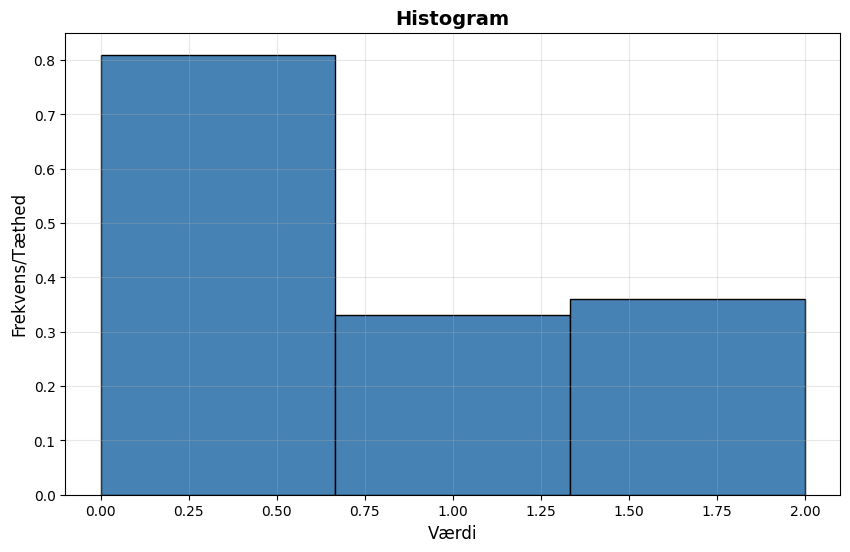

In [65]:
# Simuler kontinuert uniform: U(a, b)
# R: runif(n, min=0, max=1)
np.random.seed(62)
a = 0  # Minimum
b = 1  # Maksimum
n_sim = 50

sim_data = np.random.uniform(low=a, high=b, size=n_sim)
print(f"Gennemsnit: {np.mean(sim_data):.4f}")
print(f"Teoretisk E[X] = {(a + b) / 2:.4f}")

sim_X = np.zeros(50)

for i in range(len(sim_data)):
    sim_X[i] = F_X_inv(sim_data[i])

print(sim_X)

# Histogram: fordeling af data
plt.figure(figsize=(10, 6))
plt.hist(sim_X, bins=3, density=True, alpha=1, edgecolor='black', color='steelblue')
plt.xlabel('Værdi', fontsize=12)
plt.ylabel('Frekvens/Tæthed', fontsize=12)
plt.title('Histogram', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [67]:
# E[sim_x] 





# Konfidensinterval for middelværdi μ (ukendt populationsvarians)
# BRUG NÅR: Populationsstandardafvigelse σ er UKENDT - bruger stikprøve-std s
# Bruger T-FORDELING med df = n-1 frihedsgrader
# Antager: Data er tilnærmelsesvis normalfordelt
# CI: x̄ ± t_{α/2,n-1} × (s/√n)
# LaTeX: CI = \left[\bar{x} - t_{\alpha/2,n-1}\frac{s}{\sqrt{n}}, \bar{x} + t_{\alpha/2,n-1}\frac{s}{\sqrt{n}}\right]
alpha = 0.05  # Signifikansniveau
sample_mean = np.mean(sim_X)  # x̄ - Observeret stikprøvemiddelværdi
s = np.var(sim_X)  # s - Stikprøvestandardafvigelse (beregnet fra data)
n = 50  # Stikprøvestørrelse

df = n - 1  # Frihedsgrader
t_critical = stats.t.ppf(1 - alpha/2, df)
SE = s / np.sqrt(n)
margin_error = t_critical * SE

lower_bound = sample_mean - margin_error
upper_bound = sample_mean + margin_error

print(f"{(1-alpha)*100:.0f}% Konfidensinterval: ({lower_bound:.4f}, {upper_bound:.4f})")
print(f"Frihedsgrader: {df}")

95% Konfidensinterval: (0.5039, 0.8961)
Frihedsgrader: 49
